# Analisis Exploratorio Detallado: Video Games Sales (1980-2024)

Este notebook documenta un EDA (Exploratory Data Analysis) profundo para entender el dataset de ventas de videojuegos.

El objetivo es que cualquier persona, incluso sin contexto previo, pueda leer este documento y entender:
- que representa cada variable,
- si es cuantitativa o cualitativa,
- que problemas de calidad de datos existen,
- que columnas requieren formateo o limpieza,
- que variables aportan (o no) informacion para analisis posteriores.

## 1) Objetivos y alcance

### Objetivos del EDA
1. Auditar estructura y calidad del dataset.
2. Clasificar variables (cuantitativas/cualitativas, continuas/discretas, nominales/temporales).
3. Detectar valores faltantes, formatos incorrectos, incoherencias y potenciales duplicados.
4. Evaluar utilidad analitica de cada columna para modelado, dashboards o reportes.
5. Proponer una ruta de limpieza priorizada.

### Antes de empezar a codificar

En el siguiente bloque se configura el entorno de trabajo (librerias, opciones de visualizacion y formato de salida).

Por que se hace:
- Garantiza que todas las tablas y graficos se muestren de forma consistente.
- Mejora la legibilidad del analisis para terceros.
- Evita diferencias de formato entre ejecuciones.

In [132]:
# Configuracion general
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

### Resultado de la configuracion

El entorno queda listo para ejecutar el EDA de forma reproducible:
- Librerias cargadas correctamente.
- Estilo grafico uniforme.
- Formato de salida numerica consistente.

Interpretacion: a partir de aqui, los resultados del notebook son comparables entre ejecuciones y mas faciles de comunicar.

## 2) Carga de datos y vista inicial

### Que se va a hacer
En este bloque vamos a cargar el archivo CSV original, verificar su tamaño (filas y columnas) y observar una muestra de registros.

### Por que se hace
Este paso valida que estamos leyendo la fuente correcta y nos da una primera intuicion del contenido real del dataset (campos disponibles, formato y ejemplos de valores). Sin esta validacion inicial, cualquier analisis posterior podria basarse en una carga incorrecta.

In [133]:
# Carga del dataset
csv_path = Path('Video Games Sales (1980-2024) - Raw.csv')
df = pd.read_csv(csv_path)

print(f'Ruta: {csv_path.resolve()}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head(5)

Ruta: /home/naciscric/Documents/university/2026-1/mineria/videoGames/Video Games Sales (1980-2024) - Raw.csv
Filas: 64,016 | Columnas: 14


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4000,20.3200,6.3700,0.9900,9.8500,3.1200,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7000,19.3900,6.0600,0.6000,9.7100,3.0200,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6000,16.1500,8.4100,0.4700,5.4900,1.7800,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.8600,9.0600,0.0600,5.3300,1.4200,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1000,15.0900,6.1800,0.4100,6.0500,2.4400,06-11-2015,14-01-2018


In [134]:
# Estructura general y tipos iniciales
display(df.info())
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
img,64016,56177,/games/boxart/default.jpg,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,"6,678.0000",NaN,NaN,NaN,7.2204,1.4571,1.0000,6.4000,7.5000,8.3000,10.0000
total_sales,"18,922.0000",NaN,NaN,NaN,0.3491,0.8075,0.0000,0.0300,0.1200,0.3400,20.3200
na_sales,"12,637.0000",NaN,NaN,NaN,0.2647,0.4948,0.0000,0.0500,0.1200,0.2800,9.7600
jp_sales,"6,726.0000",NaN,NaN,NaN,0.1023,0.1688,0.0000,0.0200,0.0400,0.1200,2.1300


### Resultado e interpretacion

- El dataset contiene 64016 filas y 14 columnas.
- Se observa una mezcla de variables categoricas, numericas y temporales.
- La primera auditoria muestra faltantes muy altos en variables de ventas y puntuacion critica.

Interpretacion: el dataset es util para EDA y analisis de negocio, pero no esta listo para modelado directo sin una estrategia formal de tratamiento de nulos y consistencia.

## 3) Diccionario inicial de variables

### Que se va a hacer
Se documentaran conceptualmente las columnas del dataset y luego se calculara un perfil por variable (tipo detectado, nulos, porcentaje de nulos y cardinalidad).

### Por que se hace
Antes de limpiar o modelar, es clave entender el significado de cada variable y su estado de calidad. Esta etapa transforma un CSV en un conjunto de variables con contexto de negocio y criterios tecnicos para decidir prioridades de limpieza.

A continuacion se presenta una tabla de referencia conceptual (antes de limpiar):

- **img**: ruta de imagen de portada.
- **title**: nombre del videojuego.
- **console**: plataforma/consola.
- **genre**: genero principal.
- **publisher**: empresa publicadora.
- **developer**: estudio desarrollador.
- **critic_score**: puntuacion de critica (escala aparente 0-10).
- **total_sales**: ventas globales (aparentemente en millones de unidades).
- **na_sales, jp_sales, pal_sales, other_sales**: ventas por region.
- **release_date**: fecha de lanzamiento.
- **last_update**: fecha de ultima actualizacion del registro.

In [135]:
# Perfilado de tipos, cardinalidad y nulos por columna
summary = pd.DataFrame({
    'dtype_inicial': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(dropna=True)
}).sort_values(['pct_nulos', 'unicos'], ascending=[False, False])
summary

,dtype_inicial,nulos,pct_nulos,unicos
critic_score,float64,57338,89.5700,89
jp_sales,float64,57290,89.4900,121
na_sales,float64,51379,80.2600,320
pal_sales,float64,51192,79.9700,256
other_sales,float64,48888,76.3700,133
last_update,str,46137,72.0700,1545
total_sales,float64,45094,70.4400,482
release_date,str,7051,11.0100,7922
developer,str,17,0.0300,8862
img,str,0,0.0000,56177


### Resultado e interpretacion

El perfil por variable confirma que:
- Existen columnas con alta completitud (title, console, genre, publisher).
- Otras columnas clave tienen faltantes severos (critic_score y ventas regionales/globales).
- `img` presenta cardinalidad muy alta y baja utilidad para analitica de negocio.

Interpretacion: conviene priorizar el trabajo sobre variables de ventas, fechas y score, y tratar `img` como campo auxiliar (no analitico).

## 4) Tipificacion analitica: cuantitativa vs cualitativa

### Que se va a hacer
Se clasificara cada variable desde una mirada analitica (no solo por el dtype tecnico): cuantitativa/cualitativa, temporal/nominal y nivel de cardinalidad.

### Por que se hace
El tipo analitico determina que tecnicas aplicar: estadistica descriptiva, visualizaciones, imputacion, codificacion, agregaciones o transformaciones. Esta tipificacion evita errores comunes como tratar categorias como numericas o viceversa.

En esta seccion clasificamos cada variable de forma analitica (no solo por dtype de pandas).

In [136]:
# Clasificacion manual asistida
clasificacion = pd.DataFrame([
    ['img', 'Cualitativa nominal (identificador de recurso)', 'Alta cardinalidad', 'Puede no aportar para analisis de negocio'],
    ['title', 'Cualitativa nominal', 'Alta cardinalidad', 'Clave para agrupar; revisar duplicados por version/plataforma'],
    ['console', 'Cualitativa nominal', 'Baja/Media cardinalidad', 'Muy util para segmentacion'],
    ['genre', 'Cualitativa nominal', 'Baja cardinalidad', 'Muy util para perfil de mercado'],
    ['publisher', 'Cualitativa nominal', 'Media/Alta cardinalidad', 'Util para concentracion de mercado'],
    ['developer', 'Cualitativa nominal', 'Media/Alta cardinalidad', 'Util, pero suele tener variaciones de escritura'],
    ['critic_score', 'Cuantitativa continua', 'Escala numerica', 'Puede requerir convertir de texto a numerico y tratar nulos'],
    ['total_sales', 'Cuantitativa continua', 'Magnitud de ventas', 'Variable objetivo clave'],
    ['na_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['jp_sales', 'Cuantitativa continua', 'Magnitud regional', 'Posibles nulos/celdas vacias en CSV'],
    ['pal_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['other_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['release_date', 'Temporal', 'Fecha diaria', 'Requiere parseo de fecha'],
    ['last_update', 'Temporal', 'Fecha diaria', 'Requiere parseo de fecha y evaluar utilidad']
], columns=['variable', 'tipo_analitico', 'naturaleza', 'comentario'])

clasificacion

,variable,tipo_analitico,naturaleza,comentario
0,img,Cualitativa nominal (identificador de recurso),Alta cardinalidad,Puede no aportar para analisis de negocio
1,title,Cualitativa nominal,Alta cardinalidad,Clave para agrupar; revisar duplicados por ver...
2,console,Cualitativa nominal,Baja/Media cardinalidad,Muy util para segmentacion
3,genre,Cualitativa nominal,Baja cardinalidad,Muy util para perfil de mercado
4,publisher,Cualitativa nominal,Media/Alta cardinalidad,Util para concentracion de mercado
5,developer,Cualitativa nominal,Media/Alta cardinalidad,"Util, pero suele tener variaciones de escritura"
6,critic_score,Cuantitativa continua,Escala numerica,Puede requerir convertir de texto a numerico y...
7,total_sales,Cuantitativa continua,Magnitud de ventas,Variable objetivo clave
8,na_sales,Cuantitativa continua,Magnitud regional,Validar consistencia con total_sales
9,jp_sales,Cuantitativa continua,Magnitud regional,Posibles nulos/celdas vacias en CSV


### Resultado e interpretacion

La clasificacion analitica deja claro que:
- El nucleo cuantitativo es `critic_score` y el bloque de ventas.
- El nucleo categorico es `title`, `console`, `genre`, `publisher`, `developer`.
- `release_date` y `last_update` son temporales y requieren parseo.

Interpretacion: esta separacion facilita elegir tecnicas correctas por tipo de variable y reduce riesgo de analisis metodologicamente incorrecto.

## 5) Calidad de datos: nulos, duplicados y consistencia basica

### Que se va a hacer
Se evaluaran faltantes por columna, duplicados exactos y posibles duplicados de negocio usando llaves candidatas (por ejemplo, title + console + release_date).

### Por que se hace
La calidad de datos define la confiabilidad del analisis. Los nulos afectan comparaciones y modelos; los duplicados pueden inflar frecuencias o ventas. Detectarlos temprano permite decidir reglas de limpieza justificadas.

In [137]:
# Nulos por columna
null_table = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
null_table

,nulos,pct_nulos
critic_score,57338,89.5700
jp_sales,57290,89.4900
na_sales,51379,80.2600
pal_sales,51192,79.9700
other_sales,48888,76.3700
last_update,46137,72.0700
total_sales,45094,70.4400
release_date,7051,11.0100
developer,17,0.0300
publisher,0,0.0000


In [138]:
# Duplicados exactos y duplicados por llave de negocio aproximada
dup_exact = df.duplicated().sum()
dup_title_console_release = df.duplicated(subset=['title', 'console', 'release_date']).sum()
dup_title_console = df.duplicated(subset=['title', 'console']).sum()

print(f'Duplicados exactos: {dup_exact:,}')
print(f'Duplicados por title+console+release_date: {dup_title_console_release:,}')
print(f'Duplicados por title+console: {dup_title_console:,}')

Duplicados exactos: 0
Duplicados por title+console+release_date: 139
Duplicados por title+console: 225


In [139]:
# Muestra de posibles duplicados de negocio
potential_dups = (
    df[df.duplicated(subset=['title', 'console'], keep=False)]
    .sort_values(['title', 'console'])
    .head(30)
)
potential_dups

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
32537,/games/boxart/full_absolute-chess_3AmericaFron...,Absolute Chess,DSiW,Misc,Tasuke,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,09-08-2010,NaN
32538,/games/boxart/default.jpg,Absolute Chess,DSiW,Misc,Unknown,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55926,/games/boxart/full_2886030AmericaFrontccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Namco,NaN,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
56164,/games/boxart/8720327ccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Project ACES,8.0000,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
12460,/games/boxart/full_4008801AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Adventure,Little Orbit,WayForward Technologies,NaN,0.0600,0.0000,NaN,0.0500,0.0000,18-10-2014,17-04-2018
17417,/games/boxart/full_2043543AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Action-Adventure,Little Orbit,Way Forward,NaN,0.0100,0.0100,NaN,NaN,0.0000,18-11-2014,10-05-2019
32645,/games/boxart/default.jpg,Akaneiro: Demon Hunters,PC,Misc,Spicy Horse,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,13-06-2013,NaN
48467,/games/boxart/full_5466711AmericaFrontccc.jpg,Akaneiro: Demon Hunters,PC,Role-Playing,Spicy Horse,Spicy Horse,NaN,NaN,NaN,NaN,NaN,NaN,31-01-2013,NaN
13461,/games/boxart/2805168ccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito,NaN,0.0400,NaN,0.0400,NaN,NaN,07-12-2006,NaN
13536,/games/boxart/full_2988020JapanFrontccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito Corporation,NaN,0.0400,NaN,0.0400,NaN,NaN,07-12-2006,NaN


### Resultado e interpretacion

- No hay duplicados exactos, lo cual es positivo.
- Si aparecen duplicados de negocio (mismas claves de titulo/plataforma/fecha) que deben evaluarse caso a caso.
- Los faltantes son estructuralmente relevantes y no marginales.

Interpretacion: el problema principal no es duplicacion exacta, sino calidad semantica del registro (completitud y posible redundancia por ediciones/versiones).

## 6) Estandarizacion de formato (copia de trabajo)

### Que se va a hacer
Se creara una copia del dataframe para aplicar transformaciones de formato: limpieza de texto (trim), conversion de columnas numericas y parseo de fechas.

### Por que se hace
Normalizar tipos evita errores silenciosos y permite usar operaciones correctas (comparaciones numericas, filtros temporales, agregaciones y joins). Trabajar en copia protege el dataset original y mejora la trazabilidad del proceso.

Creamos una copia `df_work` para normalizar tipos sin perder el dataset original.

In [140]:
df_work = df.copy()

# Estandarizacion de strings (evita problemas por espacios)
str_cols = ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'release_date', 'last_update']
for col in str_cols:
    if col in df_work.columns:
        df_work[col] = df_work[col].astype('string').str.strip()

# Conversion de numericas
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in num_cols:
    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

# Parseo de fechas (formato dia-mes-anio observado en muestra)
for col in ['release_date', 'last_update']:
    df_work[col] = pd.to_datetime(df_work[col], errors='coerce', dayfirst=True)

df_work.dtypes

img                     string
title                   string
console                 string
genre                   string
publisher               string
developer               string
critic_score           float64
total_sales            float64
na_sales               float64
jp_sales               float64
pal_sales              float64
other_sales            float64
release_date    datetime64[us]
last_update     datetime64[us]
dtype: object

In [141]:
# Reperfilado post-conversion
post_summary = pd.DataFrame({
    'dtype_limpio': df_work.dtypes.astype(str),
    'nulos': df_work.isna().sum(),
    'pct_nulos': (df_work.isna().mean() * 100).round(2),
    'unicos': df_work.nunique(dropna=True)
}).sort_values(['pct_nulos', 'unicos'], ascending=[False, False])
post_summary

,dtype_limpio,nulos,pct_nulos,unicos
critic_score,float64,57338,89.5700,89
jp_sales,float64,57290,89.4900,121
na_sales,float64,51379,80.2600,320
pal_sales,float64,51192,79.9700,256
other_sales,float64,48888,76.3700,133
last_update,datetime64[us],46137,72.0700,1545
total_sales,float64,45094,70.4400,482
release_date,datetime64[us],7051,11.0100,7922
developer,string,17,0.0300,8862
img,string,0,0.0000,56177


### Resultado e interpretacion

Tras la estandarizacion en `df_work`:
- Las columnas numericas quedaron en formato numerico coherente.
- Las fechas quedaron parseadas y listas para analisis temporal.
- El porcentaje de nulos se mantiene (porque se transformo tipo, no contenido).

Interpretacion: el dataset queda tecnicamente preparado para diagnostico avanzado, aunque aun requiere decisiones de limpieza/imputacion para uso predictivo.

## 7) Consistencia interna de ventas

### Que se va a hacer
Se comparara `total_sales` contra la suma regional (`na_sales + jp_sales + pal_sales + other_sales`) para identificar discrepancias por registro.

### Por que se hace
Es una validacion de integridad de negocio: si total y desagregados no son coherentes, cualquier conclusion por mercado o por titulo puede quedar sesgada.

Dado que puede haber redondeo, se usa tolerancia.

In [142]:
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_work['regional_sum'] = df_work[regional_cols].sum(axis=1, min_count=1)
df_work['sales_diff'] = df_work['total_sales'] - df_work['regional_sum']

tol = 0.01
mask_comparable = df_work['total_sales'].notna() & df_work['regional_sum'].notna()
inconsistentes = df_work[mask_comparable & (df_work['sales_diff'].abs() > tol)]

print(f'Registros comparables: {mask_comparable.sum():,}')
print(f'Inconsistentes (|diff| > {tol}): {len(inconsistentes):,}')
print(f'Porcentaje inconsistente: {len(inconsistentes) / max(mask_comparable.sum(), 1) * 100:.2f}%')

inconsistentes[['title', 'console', 'total_sales', 'regional_sum', 'sales_diff']].head(20)

Registros comparables: 18,922
Inconsistentes (|diff| > 0.01): 2,597
Porcentaje inconsistente: 13.72%


,title,console,total_sales,regional_sum,sales_diff
0,Grand Theft Auto V,PS3,20.3200,20.3300,-0.0100
3,Grand Theft Auto V,X360,15.8600,15.8700,-0.0100
18,Call of Duty: Modern Warfare 2,PS3,10.6100,10.6200,-0.0100
19,Grand Theft Auto IV,PS3,10.5700,10.5800,-0.0100
23,Halo 4,X360,9.9600,9.9500,0.0100
41,Battlefield 3,PS3,7.2100,7.2200,-0.0100
51,Red Dead Redemption,X360,6.5000,6.4900,0.0100
58,Minecraft,PS3,6.0500,6.0600,-0.0100
76,Call of Duty: Advanced Warfare,XOne,5.2200,5.2300,-0.0100
107,Forza Motorsport 4,X360,4.6000,4.6100,-0.0100


### Resultado e interpretacion

La validacion de integridad de ventas muestra discrepancias entre `total_sales` y la suma de ventas regionales en un subconjunto no menor.

Interpretacion:
- Parte de las diferencias puede venir de redondeos o actualizaciones parciales.
- Sin embargo, esta inconsistencia debe considerarse en analisis por region.
- Para reportes sensibles, conviene documentar la regla: usar `total_sales` oficial o recomputar desde regiones segun el objetivo.

## 8) Distribuciones numericas y outliers

### Que se va a hacer
Se describiran estadisticamente las variables numericas, se detectaran outliers con IQR y se visualizaran distribuciones con histogramas y curvas KDE.

### Por que se hace
Permite entender asimetria, dispersion, concentracion de valores y presencia de extremos. Esto es clave para decidir transformaciones (por ejemplo, log), robustez de metricas y estrategias de modelado.

Analizamos dispersion, asimetria y posibles valores extremos de variables cuantitativas.

In [143]:
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_work[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
critic_score,"6,678.0000",7.2204,1.4571,1.0000,3.0000,4.4000,6.4000,7.5000,8.3000,9.1000,9.5000,10.0000
total_sales,"18,922.0000",0.3491,0.8075,0.0000,0.0000,0.0000,0.0300,0.1200,0.3400,1.3700,3.5400,20.3200
na_sales,"12,637.0000",0.2647,0.4948,0.0000,0.0000,0.0100,0.0500,0.1200,0.2800,0.9900,2.1864,9.7600
jp_sales,"6,726.0000",0.1023,0.1688,0.0000,0.0000,0.0000,0.0200,0.0400,0.1200,0.3900,0.8250,2.1300
pal_sales,"12,824.0000",0.1495,0.3927,0.0000,0.0000,0.0000,0.0100,0.0400,0.1400,0.5900,1.6777,9.8500
other_sales,"15,128.0000",0.0430,0.1266,0.0000,0.0000,0.0000,0.0000,0.0100,0.0300,0.1800,0.5373,3.1200


In [144]:
# Conteo de outliers por metodo IQR
iqr_rows = []
for col in num_cols:
    s = df_work[col].dropna()
    if s.empty:
        iqr_rows.append([col, np.nan, np.nan, np.nan, np.nan, 0, 0.0])
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_count = ((s < lower) | (s > upper)).sum()
    out_pct = out_count / len(s) * 100
    iqr_rows.append([col, q1, q3, lower, upper, int(out_count), round(out_pct, 2)])

iqr_df = pd.DataFrame(iqr_rows, columns=['variable', 'Q1', 'Q3', 'lim_inf', 'lim_sup', 'n_outliers', 'pct_outliers'])
iqr_df.sort_values('pct_outliers', ascending=False)

,variable,Q1,Q3,lim_inf,lim_sup,n_outliers,pct_outliers
5,other_sales,0.0000,0.0300,-0.0450,0.0750,1931,12.7600
4,pal_sales,0.0100,0.1400,-0.1850,0.3350,1409,10.9900
1,total_sales,0.0300,0.3400,-0.4350,0.8050,1963,10.3700
2,na_sales,0.0500,0.2800,-0.2950,0.6250,1210,9.5800
3,jp_sales,0.0200,0.1200,-0.1300,0.2700,630,9.3700
0,critic_score,6.4000,8.3000,3.5500,11.1500,148,2.2200


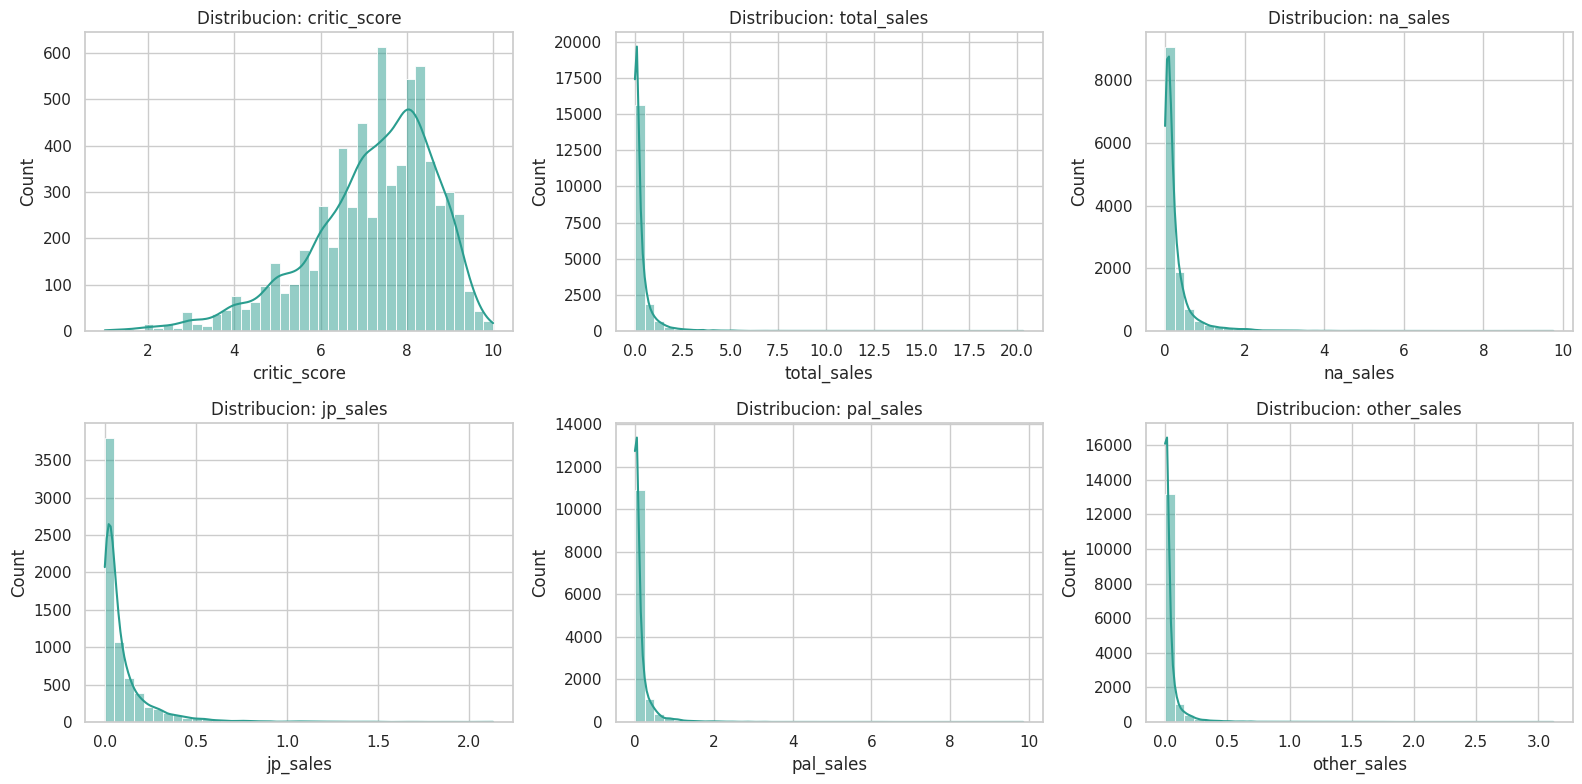

In [145]:
# Visualizaciones de distribucion
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.histplot(df_work[col], bins=40, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'Distribucion: {col}')
plt.tight_layout()
plt.show()

### Resultado e interpretacion (graficos de distribucion)

Interpretacion de los histogramas:
- `critic_score` muestra mayor densidad entre 6 y 9, con sesgo hacia calificaciones altas.
- Las variables de ventas (`total_sales` y regionales) presentan fuerte asimetria positiva: muchos juegos con ventas bajas y pocos titulos superventas (cola larga).
- Los outliers en ventas son esperables por fenomeno de blockbusters.

Implicacion analitica:
- Conviene considerar transformaciones como `log1p` para modelado.
- Medidas robustas (mediana, percentiles) suelen ser mas informativas que la media en estas variables.

## 9) Analisis temporal

### Que se va a hacer
Se evaluara la cobertura de fechas, sus rangos minimos/maximos y la evolucion de cantidad de juegos por anio de lanzamiento.

### Por que se hace
El eje temporal permite validar plausibilidad historica del dataset y detectar periodos con picos, caidas o posibles sesgos de cobertura.

Se revisa cobertura temporal y coherencia de fechas.

In [146]:
date_cols = ['release_date', 'last_update']
for col in date_cols:
    s = df_work[col].dropna()
    print(f'\n{col}')
    if len(s) == 0:
        print('  Sin datos parseables')
        continue
    print(f'  Min: {s.min().date()} | Max: {s.max().date()} | Nulos: {df_work[col].isna().sum():,}')

df_work['release_year'] = df_work['release_date'].dt.year
year_counts = df_work['release_year'].value_counts(dropna=True).sort_index()
year_counts.tail(20)


release_date
  Min: 1971-12-03 | Max: 2024-12-31 | Nulos: 7,051

last_update
  Min: 2017-11-28 | Max: 2024-01-28 | Nulos: 46,137


release_year
2,005.0000    1810
2,006.0000    2096
2,007.0000    2525
2,008.0000    2936
2,009.0000    4360
2,010.0000    3586
2,011.0000    3386
2,012.0000    1584
2,013.0000    1740
2,014.0000    2896
2,015.0000    1680
2,016.0000    1352
2,017.0000    1558
2,018.0000    1538
2,019.0000    1290
2,020.0000    1452
2,021.0000     422
2,022.0000     168
2,023.0000     108
2,024.0000      22
Name: count, dtype: int64

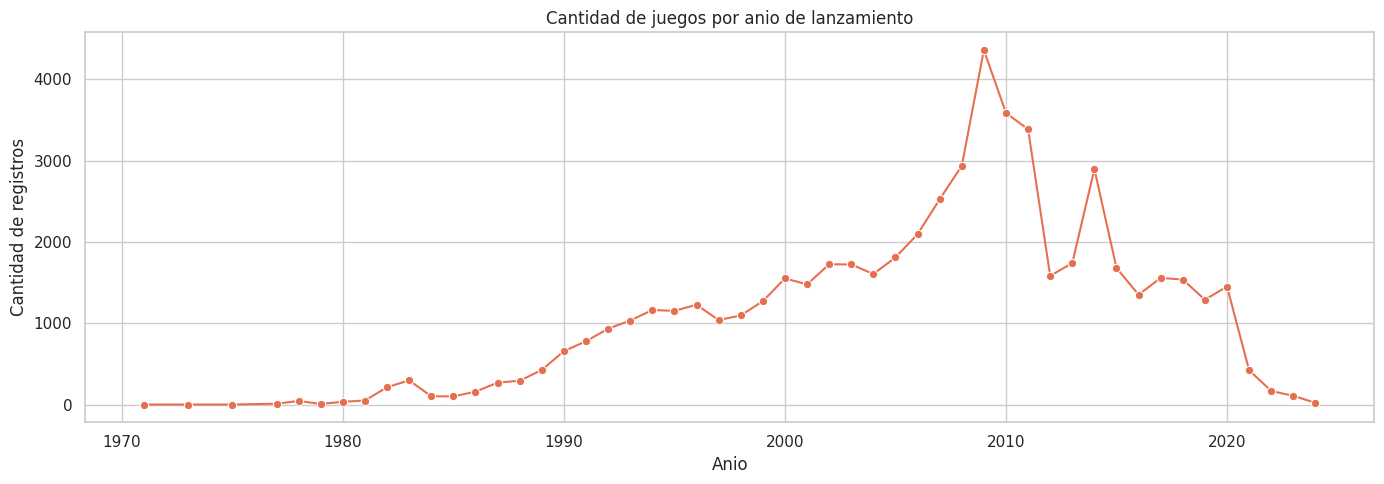

In [147]:
# Evolucion de lanzamientos por anio
plt.figure(figsize=(14, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#e76f51')
plt.title('Cantidad de juegos por anio de lanzamiento')
plt.xlabel('Anio')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

### Resultado e interpretacion (grafico temporal)

El grafico de lanzamientos por anio evidencia una expansion fuerte hasta el periodo de maximo volumen y luego una reduccion progresiva.

Interpretacion:
- La forma de la curva sugiere cambios estructurales del mercado (ciclos de consolas, digitalizacion y cobertura desigual de fuentes).
- La presencia de fechas muy antiguas o extremos puntuales debe validarse como posible ruido de registro o convenciones de carga (por ejemplo, fechas por defecto).

Implicacion: para analisis historicos finos conviene filtrar o etiquetar observaciones con fechas potencialmente anomalias.

## 10) Variables cualitativas: cardinalidad y concentracion

### Que se va a hacer
Se calculara cardinalidad de variables categoricas y se analizaran las categorias mas frecuentes mediante tablas y graficos de barras.

### Por que se hace
Ayuda a identificar variables con alta fragmentacion, categorias dominantes y posibles candidatos a agrupacion o normalizacion de etiquetas.

Medimos cuales categorias dominan y donde hay alta fragmentacion.

In [148]:
cat_cols = ['console', 'genre', 'publisher', 'developer', 'title']

cardinality = pd.DataFrame({
    'n_unicos': [df_work[c].nunique(dropna=True) for c in cat_cols],
    'pct_unicos_vs_filas': [df_work[c].nunique(dropna=True) / len(df_work) * 100 for c in cat_cols]
}, index=cat_cols).sort_values('n_unicos', ascending=False)

cardinality

,n_unicos,pct_unicos_vs_filas
title,39798,62.1688
developer,8862,13.8434
publisher,3383,5.2846
console,81,0.1265
genre,20,0.0312


In [149]:
# Top categorias mas frecuentes
for c in ['console', 'genre', 'publisher', 'developer']:
    print(f'\n=== Top 15 de {c} ===')
    display(df_work[c].value_counts(dropna=False).head(15).to_frame('frecuencia'))


=== Top 15 de console ===


,frecuencia
console,
PC,12617
PS2,3565
DS,3288
PS4,2878
PS,2707
NS,2337
XBL,2120
PSN,2004
XOne,1963



=== Top 15 de genre ===


,frecuencia
genre,
Misc,9304
Action,8557
Adventure,6260
Role-Playing,5721
Sports,5586
Shooter,5410
Platform,4001
Strategy,3685
Puzzle,3521



=== Top 15 de publisher ===


,frecuencia
publisher,
Unknown,8842
Sega,2207
Ubisoft,1663
Electronic Arts,1619
Activision,1582
Konami,1544
Nintendo,1476
Sony Computer Entertainment,1372
Microsoft,1272



=== Top 15 de developer ===


,frecuencia
developer,
Unknown,4435
Konami,976
Sega,915
Capcom,870
Namco,489
Square Enix,425
SNK Corporation,408
EA Canada,396
Hudson Soft,394


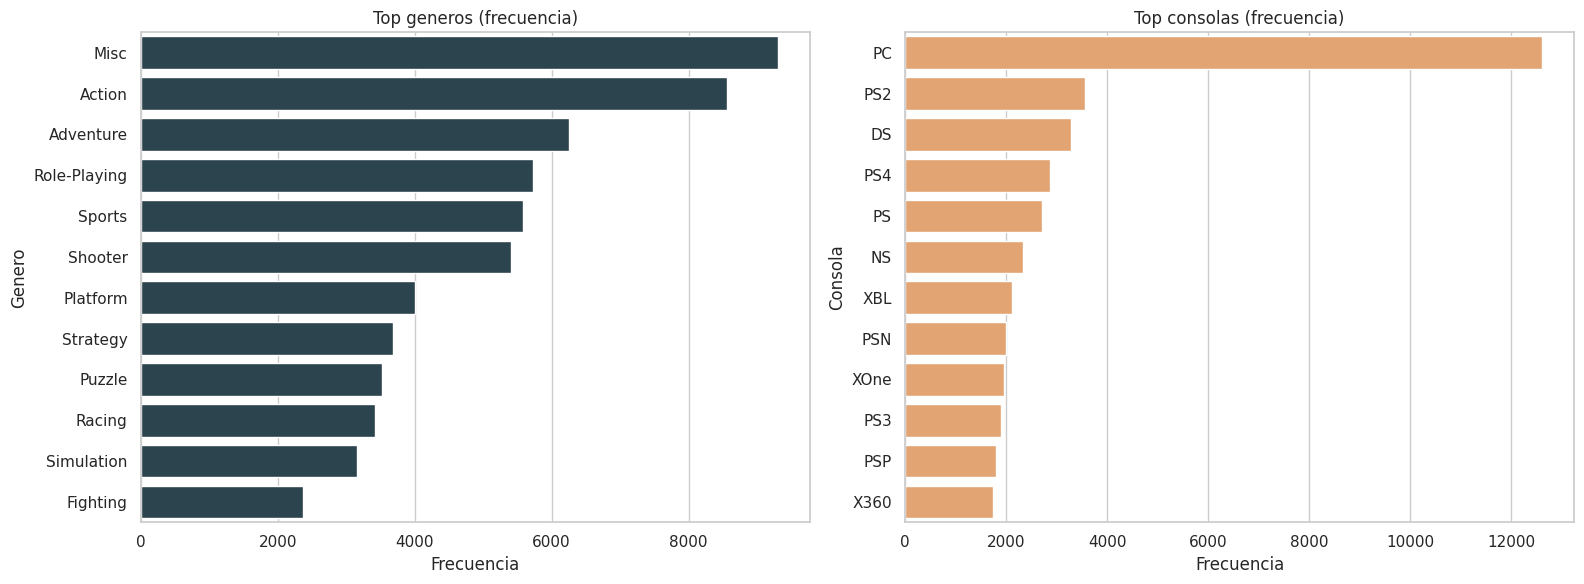

In [150]:
# Barras de genero y consola
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_genre = df_work['genre'].value_counts().head(12)
sns.barplot(x=top_genre.values, y=top_genre.index, ax=axes[0], color='#264653')
axes[0].set_title('Top generos (frecuencia)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Genero')

top_console = df_work['console'].value_counts().head(12)
sns.barplot(x=top_console.values, y=top_console.index, ax=axes[1], color='#f4a261')
axes[1].set_title('Top consolas (frecuencia)')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Consola')

plt.tight_layout()
plt.show()

### Resultado e interpretacion (graficos categoricos)

Los graficos de barras muestran concentracion clara en ciertas consolas y generos.

Interpretacion:
- Existe una larga cola de categorias menos frecuentes y un conjunto pequeno de categorias dominantes.
- `PC` aparece como plataforma con gran peso en cantidad de registros.
- En genero, `Misc`, `Action` y `Adventure` lideran por frecuencia.

Implicacion: para modelado o segmentacion, puede ser util agrupar categorias raras y analizar sesgo de representatividad por plataforma/genero.

## 11) Potencial analitico de variables

### Que se va a hacer
Se mediran relaciones entre variables cuantitativas usando correlaciones y visualizaciones (heatmap y scatter).

### Por que se hace
Esto permite estimar capacidad explicativa entre variables, detectar relaciones fuertes esperadas y evitar interpretaciones incorrectas sobre causalidad.

Aqui evaluamos que variables suelen ser mas informativas para analisis de negocio.

In [151]:
# Correlaciones entre variables cuantitativas
corr = df_work[['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']].corr()
corr

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
critic_score,1.0000,0.2812,0.3003,0.1474,0.2467,0.2438
total_sales,0.2812,1.0000,0.9141,0.2125,0.9074,0.8593
na_sales,0.3003,0.9141,1.0000,0.0651,0.6845,0.6875
jp_sales,0.1474,0.2125,0.0651,1.0000,0.1318,0.0827
pal_sales,0.2467,0.9074,0.6845,0.1318,1.0000,0.8170
other_sales,0.2438,0.8593,0.6875,0.0827,0.8170,1.0000


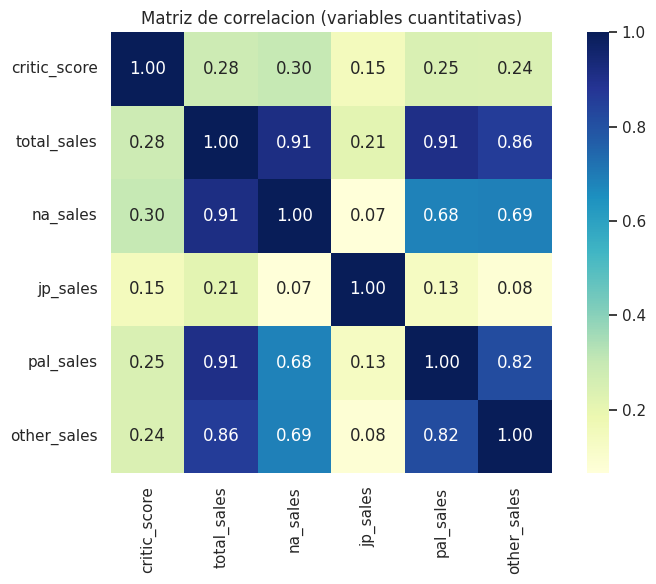

In [152]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f', square=True)
plt.title('Matriz de correlacion (variables cuantitativas)')
plt.tight_layout()
plt.show()

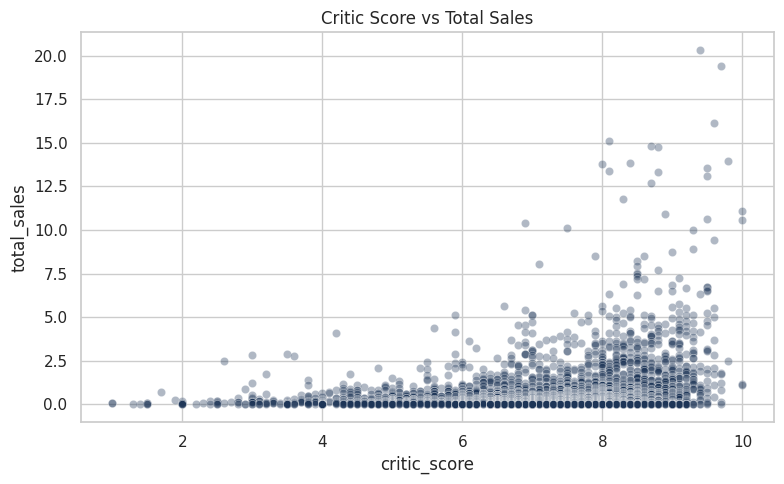

Coeficiente de correlacion (Pearson): 0.281


In [153]:
# Ejemplo: relacion critic_score vs total_sales
sample_scatter = df_work[['critic_score', 'total_sales']].dropna()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_scatter, x='critic_score', y='total_sales', alpha=0.35, s=35, color='#1d3557')
plt.title('Critic Score vs Total Sales')
plt.xlabel('critic_score')
plt.ylabel('total_sales')
plt.tight_layout()
plt.show()

print(f'Coeficiente de correlacion (Pearson): {sample_scatter.corr().iloc[0,1]:.3f}')

### Resultado e interpretacion (heatmap y scatter)

Interpretacion del heatmap:
- `total_sales` se correlaciona fuertemente con ventas regionales (esperable porque lo componen).
- `jp_sales` tiene relacion mas baja con NA/PAL, lo que sugiere dinamicas de mercado parcialmente diferentes.
- `critic_score` muestra correlacion positiva moderada con ventas, no deterministica.

Interpretacion del scatter `critic_score` vs `total_sales`:
- Se observa tendencia positiva general, pero con alta dispersion.
- Existen juegos con alta puntuacion y ventas modestas, y algunos con ventas muy altas concentrados en rangos altos de score.

Implicacion: el score critico ayuda a explicar ventas, pero no basta por si solo; deben incorporarse otras variables (franquicia, consola, genero, marketing, ciclo temporal).

## 12) Diagnostico variable por variable (accionable)

### Que se va a hacer
Se consolidara una matriz final por columna con valor analitico, riesgos de calidad y accion recomendada.

### Por que se hace
Transforma hallazgos tecnicos en decisiones operativas concretas para limpieza, seleccion de variables y preparacion de la version final del dataset.

La siguiente tabla resume, para cada columna, su utilidad y acciones recomendadas.

In [154]:
diagnostico = pd.DataFrame([
    ['img', 'Baja para negocio', 'Muchos valores unicos; es referencia multimedia', 'Mantener solo si se requiere visualizacion de portadas'],
    ['title', 'Muy alta', 'Posibles duplicados por ediciones/plataformas', 'Estandarizar texto y definir llave de juego'],
    ['console', 'Alta', 'Variantes de etiqueta posibles', 'Normalizar catalogo de consolas'],
    ['genre', 'Alta', 'Puede haber etiquetas inconsistentes', 'Consolidar categorias similares si aplica'],
    ['publisher', 'Media/Alta', 'Alta cardinalidad y posibles variantes', 'Limpieza de nombres (trim/case/diccionario)'],
    ['developer', 'Media/Alta', 'Alta cardinalidad y abreviaciones', 'Normalizacion opcional por diccionario'],
    ['critic_score', 'Alta', 'Nulos y tipo potencialmente mixto', 'Convertir a numerico y evaluar imputacion/no imputacion'],
    ['total_sales', 'Critica', 'Outliers esperables (hits globales)', 'Mantener; considerar escala log para modelado'],
    ['na_sales', 'Alta', 'Debe ser coherente con total_sales', 'Validar suma regional'],
    ['jp_sales', 'Alta', 'Nulos/celdas vacias presentes', 'Convertir a numerico y decidir imputacion'],
    ['pal_sales', 'Alta', 'Nulos posibles', 'Convertir y auditar consistencia'],
    ['other_sales', 'Media/Alta', 'Nulos posibles', 'Convertir y auditar consistencia'],
    ['release_date', 'Muy alta', 'Formato string en origen', 'Parsear fecha y derivar anio/mes/decada'],
    ['last_update', 'Media', 'No describe negocio directamente', 'Evaluar si aporta; podria descartarse segun objetivo']
], columns=['variable', 'valor_analitico', 'riesgos_detectados', 'accion_recomendada'])

diagnostico

,variable,valor_analitico,riesgos_detectados,accion_recomendada
0,img,Baja para negocio,Muchos valores unicos; es referencia multimedia,Mantener solo si se requiere visualizacion de ...
1,title,Muy alta,Posibles duplicados por ediciones/plataformas,Estandarizar texto y definir llave de juego
2,console,Alta,Variantes de etiqueta posibles,Normalizar catalogo de consolas
3,genre,Alta,Puede haber etiquetas inconsistentes,Consolidar categorias similares si aplica
4,publisher,Media/Alta,Alta cardinalidad y posibles variantes,Limpieza de nombres (trim/case/diccionario)
5,developer,Media/Alta,Alta cardinalidad y abreviaciones,Normalizacion opcional por diccionario
6,critic_score,Alta,Nulos y tipo potencialmente mixto,Convertir a numerico y evaluar imputacion/no i...
7,total_sales,Critica,Outliers esperables (hits globales),Mantener; considerar escala log para modelado
8,na_sales,Alta,Debe ser coherente con total_sales,Validar suma regional
9,jp_sales,Alta,Nulos/celdas vacias presentes,Convertir a numerico y decidir imputacion


### Resultado e interpretacion final del diagnostico

La matriz accionable resume una conclusion central: el dataset tiene alto valor analitico, pero requiere un pipeline de limpieza documentado para asegurar interpretabilidad y reproducibilidad.

Lectura recomendada:
1. Variables criticas de negocio: `total_sales`, ventas regionales, `critic_score`, `release_date`.
2. Variables auxiliares o de contexto: `publisher`, `developer`, `console`, `genre`.
3. Variable de baja utilidad analitica directa: `img` (salvo usos visuales/catalogo).

Con esta base, el siguiente paso natural es construir una version "curada" del dataset y formalizar reglas de imputacion/consistencia.

## 13) Hallazgos clave y plan de limpieza priorizado

### Hallazgos clave
1. El dataset mezcla variables de identificacion, categoricas, numericas y temporales, con distintos niveles de calidad.
2. Las variables de ventas son el nucleo del analisis y requieren chequeo de coherencia (`total_sales` vs suma regional).
3. `critic_score` suele presentar faltantes y necesita conversion robusta a numerico.
4. `release_date` y `last_update` requieren parseo de fecha para analitica temporal.
5. Variables como `publisher` y `developer` son utiles, pero pueden requerir normalizacion por alta cardinalidad y escritura inconsistente.
6. `img` normalmente tiene bajo valor para analitica de negocio; se conserva solo para casos de catalogo visual.

## 15) Que se puede hallar en este dataset para un usuario final

### Usuario final objetivo
Para aterrizar el valor de negocio, pensemos en un usuario final concreto: **Analista de marketing y portafolio en una publicadora de videojuegos**.

### Hallazgos que este usuario puede obtener
1. **Que consolas y generos concentran mas oferta y traccion comercial**.
2. **Que mercados regionales (NA, JP, PAL, Other) son mas relevantes por tipo de juego**.
3. **Que tan alineadas estan las ventas con la recepcion critica** (critic_score vs ventas).
4. **Como cambia el volumen de lanzamientos a lo largo del tiempo** y en que periodos hubo mayor saturacion.
5. **Que publishers/developers tienen mayor presencia** y donde existe alta competencia.

### Valor practico para decisiones
- Priorizar en que plataformas lanzar o reforzar campañas.
- Ajustar presupuesto de marketing segun region y genero.
- Definir posicionamiento de titulos con foco en calidad percibida vs potencial de ventas.
- Identificar nichos menos saturados para nuevas publicaciones.

### Limitacion importante
El dataset permite analisis descriptivo y de patrones, pero **no prueba causalidad** por si solo (por ejemplo, no se puede afirmar que una nota critica cause ventas altas sin variables adicionales).

## 16) Preguntas que se pueden responder con este dataset

### Preguntas de negocio y analitica
1. Cuales son los generos con mayor volumen de lanzamientos y mayor nivel de ventas totales?
2. Que consolas concentran mas juegos y cuales muestran mejor desempeno comercial?
3. Como se distribuyen las ventas por region segun genero o consola?
4. Existen diferencias claras entre el mercado japones y los mercados NA/PAL para ciertos tipos de juegos?
5. Que relacion hay entre critic_score y total_sales?
6. Que publishers y developers tienen mayor presencia en el dataset?
7. En que periodos historicos se concentran mas lanzamientos?
8. Hay evidencia de saturacion por consola o genero en determinados anios?
9. Que tan consistente es total_sales respecto de la suma regional?
10. Que variables aportan mas valor para un dashboard ejecutivo y cuales son solo auxiliares?

## 17) Por donde empezar la limpieza y como hacerlo

### Prioridad de limpieza (orden recomendado)
1. **Variables de ventas**: `total_sales`, `na_sales`, `jp_sales`, `pal_sales`, `other_sales`.
2. **Variable de calidad/score**: `critic_score`.
3. **Variables temporales**: `release_date`, `last_update`.
4. **Variables categoricas de entidad**: `publisher`, `developer`, `console`, `genre`, `title`.
5. **Variable auxiliar**: `img`.

### Como limpiar cada bloque

#### 1) Ventas (primer bloque critico)
- Convertir a numerico con manejo robusto de errores (`coerce`).
- Validar negativos y valores imposibles.
- Crear control de consistencia: diferencia entre `total_sales` y suma regional.
- Definir regla de negocio: si hay discrepancia, usar `total_sales` oficial o recalcular desde regiones (documentar criterio).

#### 2) Critic score
- Confirmar rango valido esperado (0-10).
- Revisar nulos: mantener como faltantes informativos o imputar segun objetivo.
- Si se modela, evaluar imputacion por grupo (genero/consola) y comparar contra no imputar.

#### 3) Fechas
- Parsear con dayfirst.
- Verificar fechas fuera de rango razonable.
- Derivar columnas analiticas: anio, mes, decada.
- Marcar posibles anomalias (fechas por defecto o placeholders).

#### 4) Categoricas
- Estandarizar texto: trim, mayusculas/minusculas, normalizacion basica.
- Unificar alias o variantes ortograficas en publisher/developer.
- Evaluar categorias raras en genero/consola para agrupacion cuando corresponda.

#### 5) Img
- Mantener solo si se usara en catalogo visual.
- Excluir en modelado y en metricas de negocio para evitar ruido.